<a href="https://colab.research.google.com/github/KaryMF/23-II-2026/blob/main/Clasificaci%C3%B3n_mediante_%C3%A1rboles_de_decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Librerías importadas correctamente


Saving isc31_act2_estaciones_madrid.csv to isc31_act2_estaciones_madrid.csv
📊 Dimensiones del dataset: (7918, 16)

 📋Columnas disponibles:
['ANO', 'MES', 'DIA', 'MUNICIPIO', 'ESTACION', 'SO2', 'CO', 'NO', 'NO2', 'PM2.5', 'PM10', 'NOx', 'O3', 'TOL', 'BEN', 'EBE']

 📈Tipos de datos:
ANO            int64
MES            int64
DIA            int64
MUNICIPIO      int64
ESTACION       int64
SO2          float64
CO           float64
NO           float64
NO2          float64
PM2.5        float64
PM10         float64
NOx          float64
O3           float64
TOL          float64
BEN          float64
EBE          float64
dtype: object

 ❌ Valores nulos por columna:
ANO             0
MES             0
DIA             0
MUNICIPIO       0
ESTACION        0
SO2          6363
CO           6335
NO             17
NO2            17
PM2.5        5345
PM10         3721
NOx            17
O3           3652
TOL          6011
BEN          6033
EBE          6033
dtype: int64

🏭 Datos para la estación 8: 330 reg

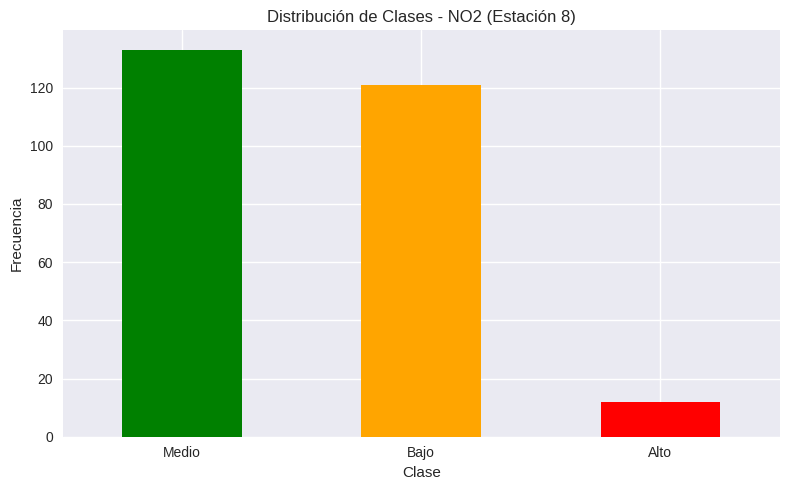

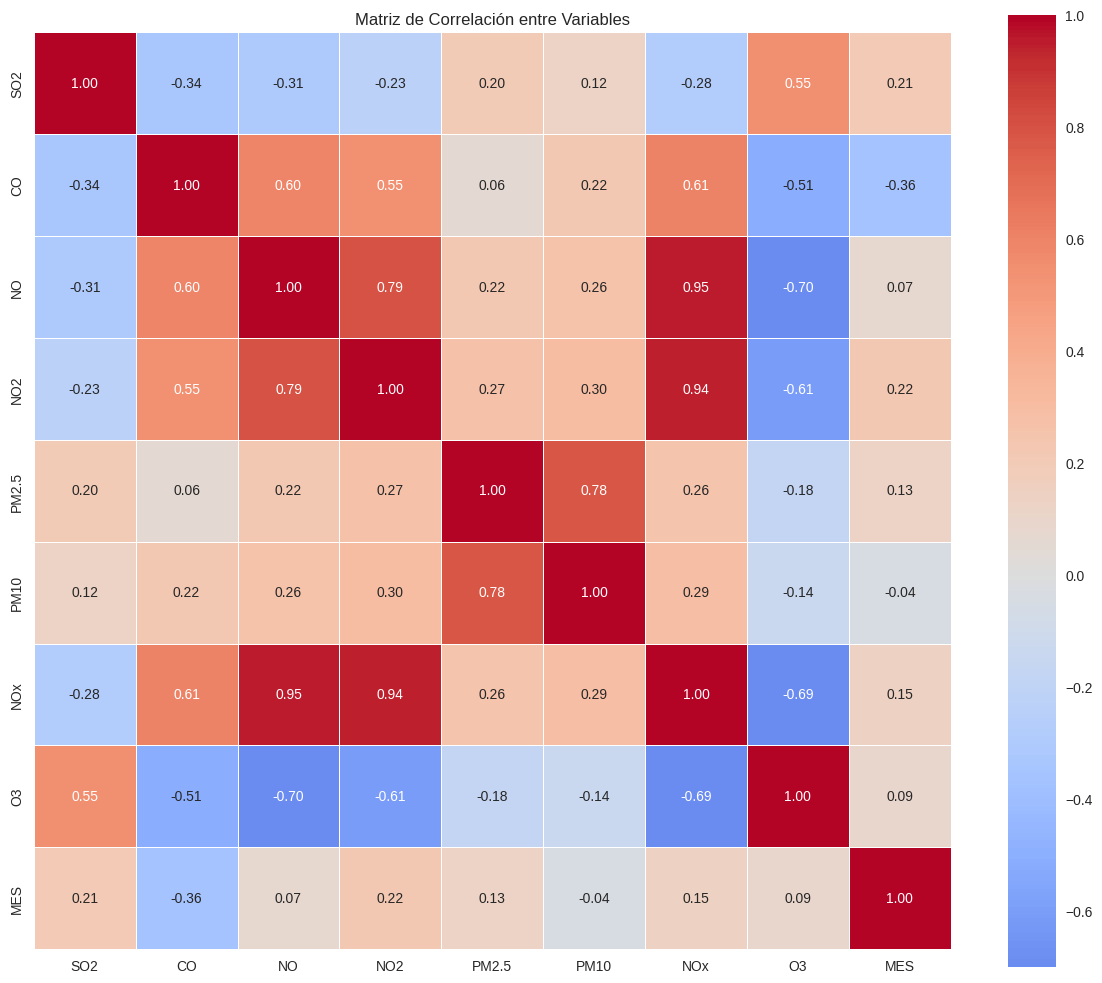


🔗 Correlaciones con NO2 (ordenadas):
NOx      0.942392
NO       0.794954
CO       0.545505
PM10     0.301786
PM2.5    0.265836
MES      0.221339
SO2     -0.229335
O3      -0.607711
Name: NO2, dtype: float64

📌 Atributos seleccionados (correlación > 0.3):
['NOx', 'NO', 'CO', 'PM10', 'O3']

🔢 Clases codificadas: ['Alto' 'Bajo' 'Medio']

📐 División de datos:
  - Entrenamiento: 159 muestras (59.8%)
  - Validación: 53 muestras (19.9%)
  - Test: 54 muestras (20.3%)

🌳 Árbol de Decisión - Resultados:
  - Accuracy Train: 1.0000
  - Accuracy Val: 0.8491
  - Accuracy Test: 0.9259
Fitting 5 folds for each of 90 candidates, totalling 450 fits

⚙️ Mejores parámetros encontrados:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
📈 Mejor accuracy en validación cruzada: 0.8931

✅ Resultados del Modelo Optimizado (Test):
  - Accuracy: 0.9074
  - Precision: 0.8848
  - Recall: 0.9074
  - F1-Score: 0.8910

📋 Reporte de Clasificación:
              precision    recall  f

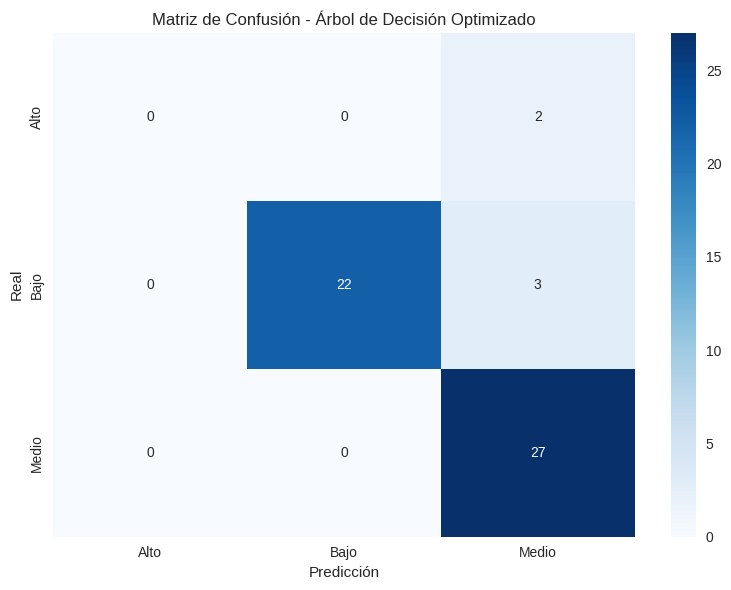

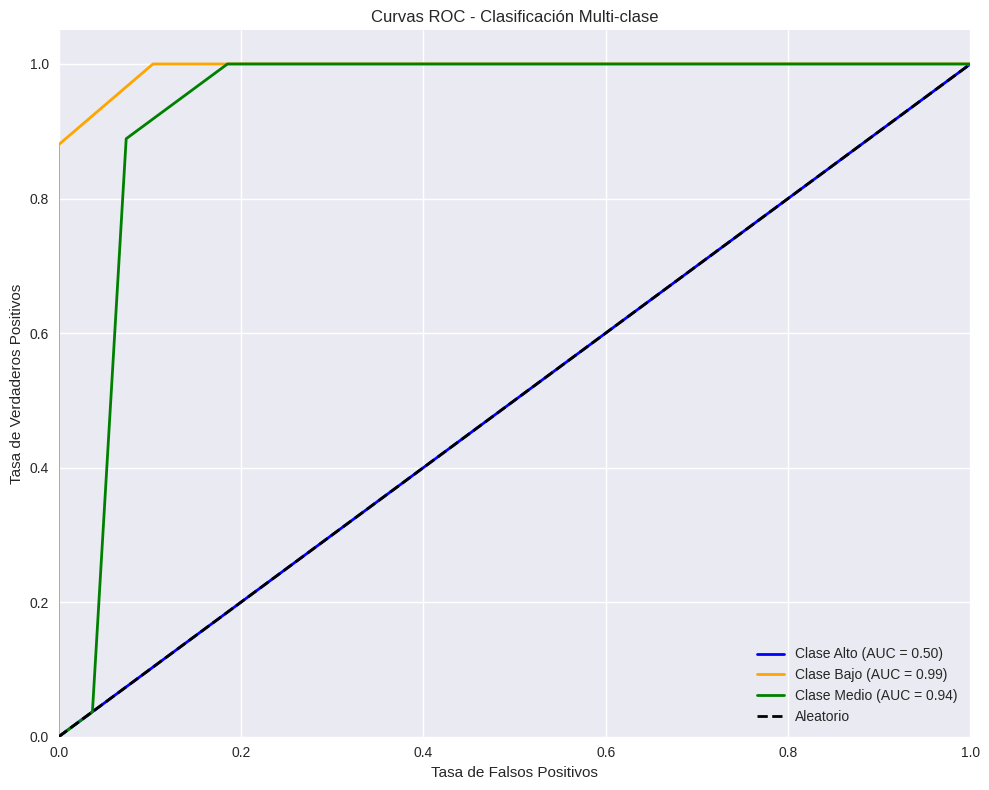

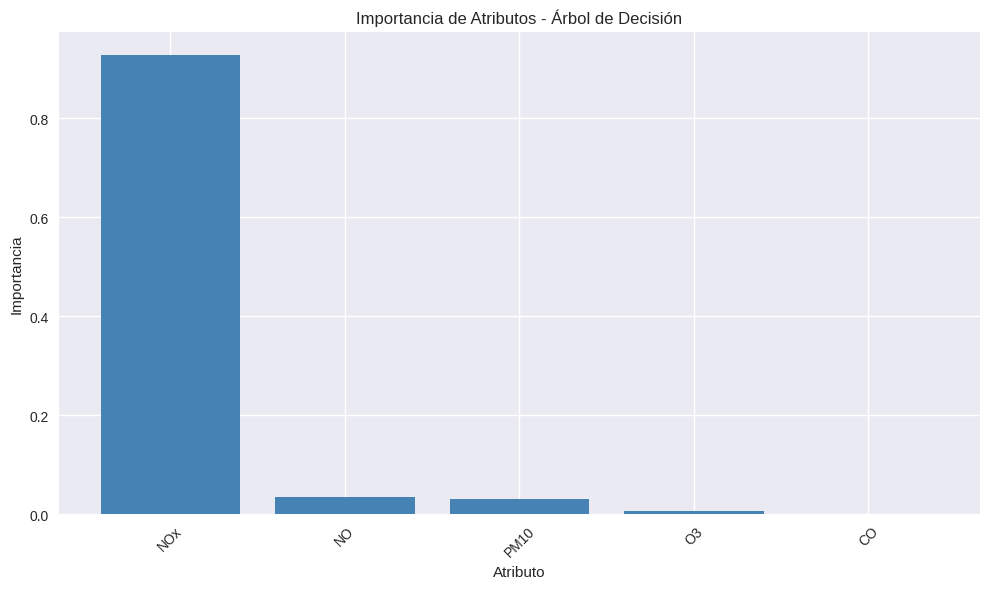


📊 Importancia de atributos:
  NOx: 0.9287
  NO: 0.0342
  PM10: 0.0304
  O3: 0.0067
  CO: 0.0000


<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

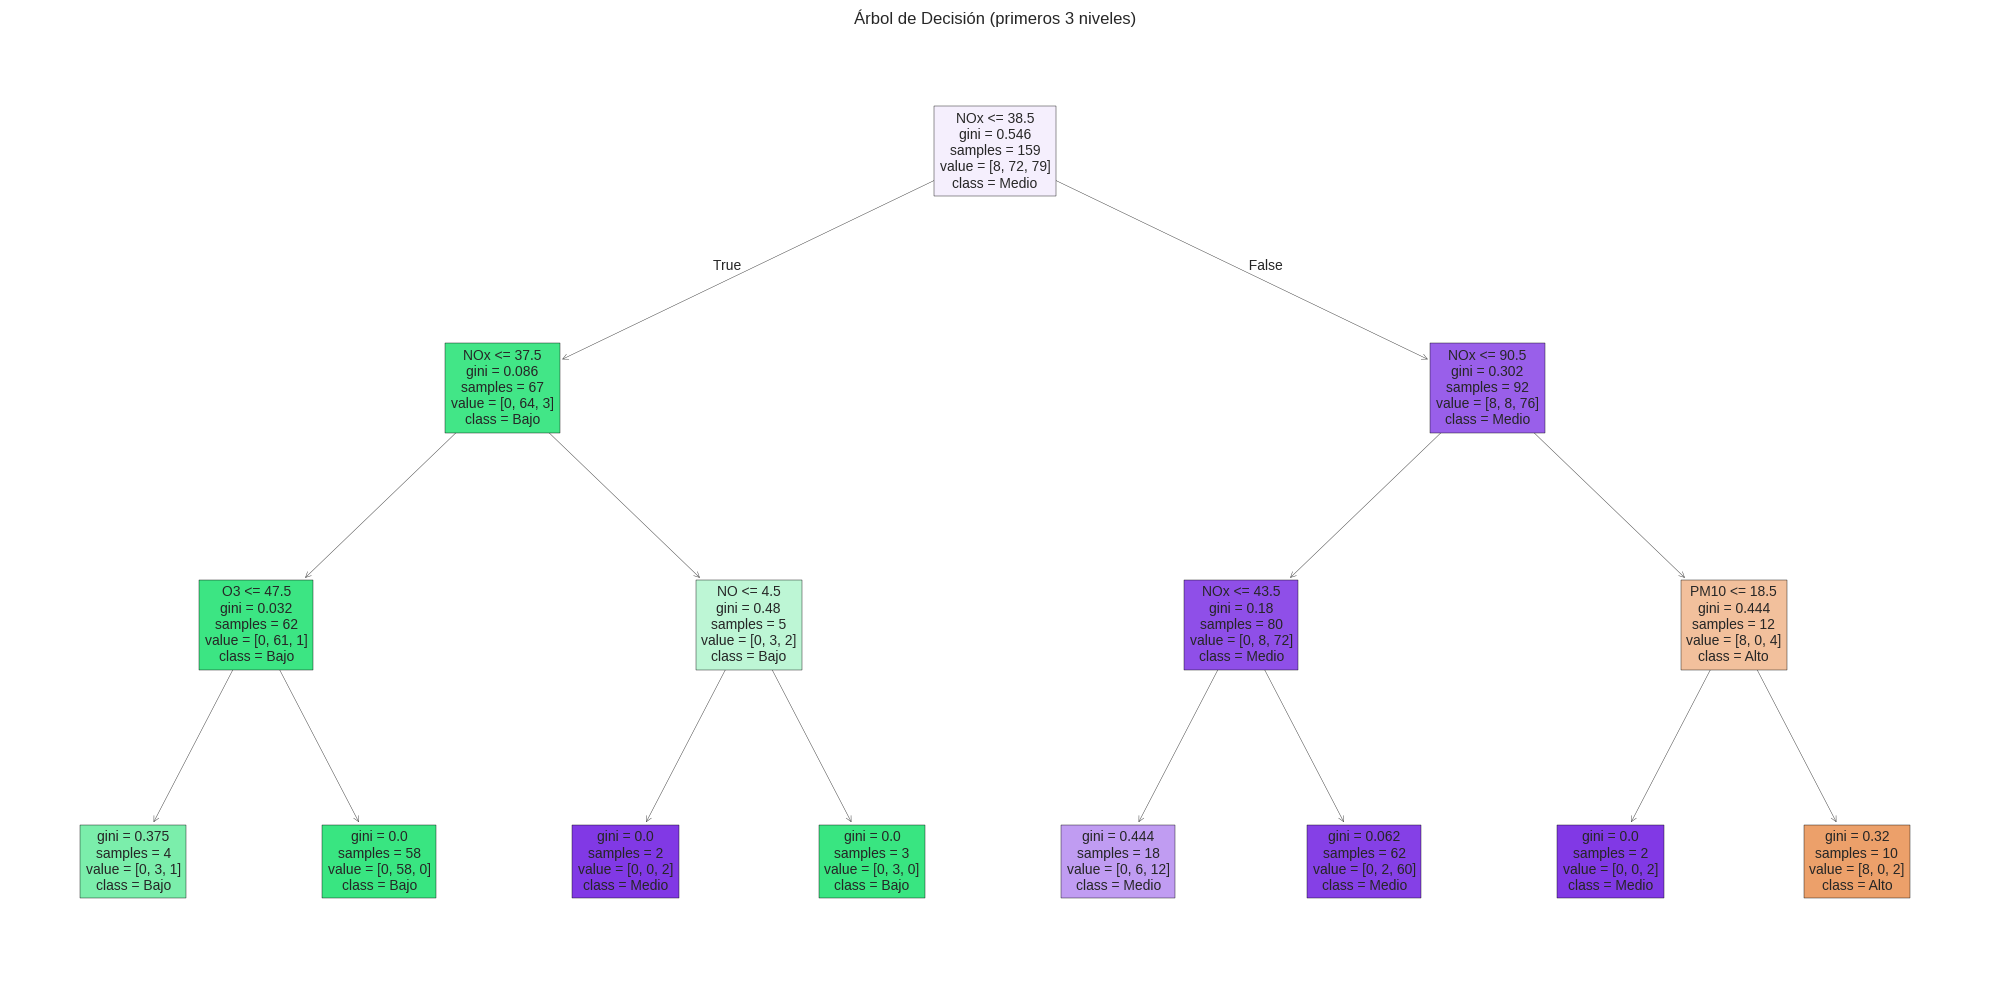


📊 COMPARACIÓN DE MODELOS

🌲 Árbol Decisión:
  Accuracy: 0.9074
  F1-Score: 0.8910

🌲 Random Forest:
  Accuracy: 0.9074
  F1-Score: 0.8998

🌲 Gradient Boosting:
  Accuracy: 0.9444
  F1-Score: 0.9272


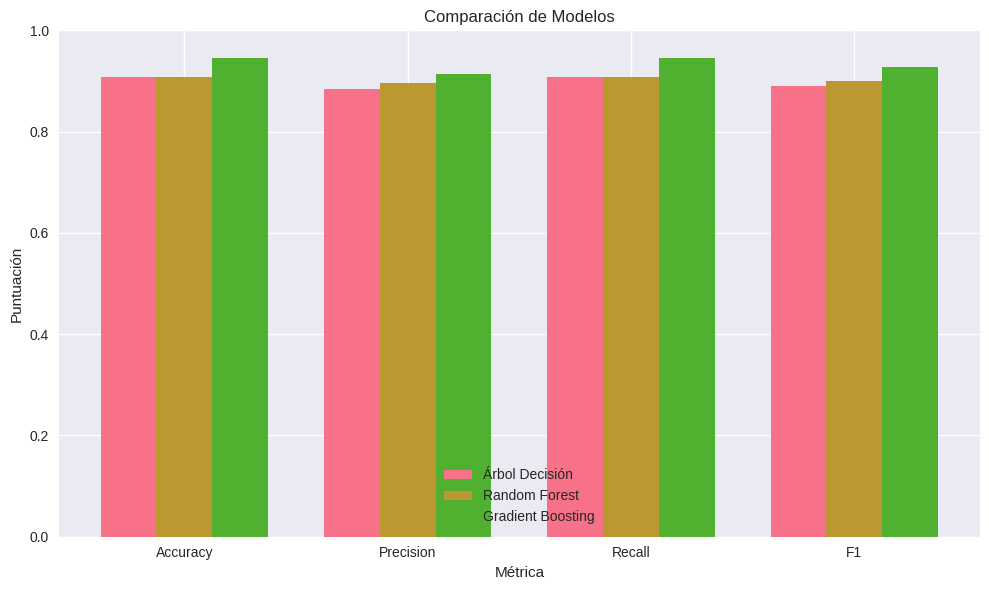


🔬 EXPERIMENTO: Eliminar variable más correlacionada
Variable más correlacionada con NO2: NOx
Atributos después de eliminar: ['NO', 'CO', 'PM10', 'O3']

📈 Resultados:
  - Accuracy original (5 atributos): 0.9074
  - Accuracy reducido (4 atributos): 0.8148
  - Diferencia: 0.0926

🌍 EXTENSIÓN: Múltiples Estaciones
🏭 Estación 8: Accuracy = 0.9074 (266 registros)
⚠️ Estación 17: Datos insuficientes (0 registros)
⚠️ Estación 36: Datos insuficientes (0 registros)
⚠️ Estación 50: Datos insuficientes (0 registros)


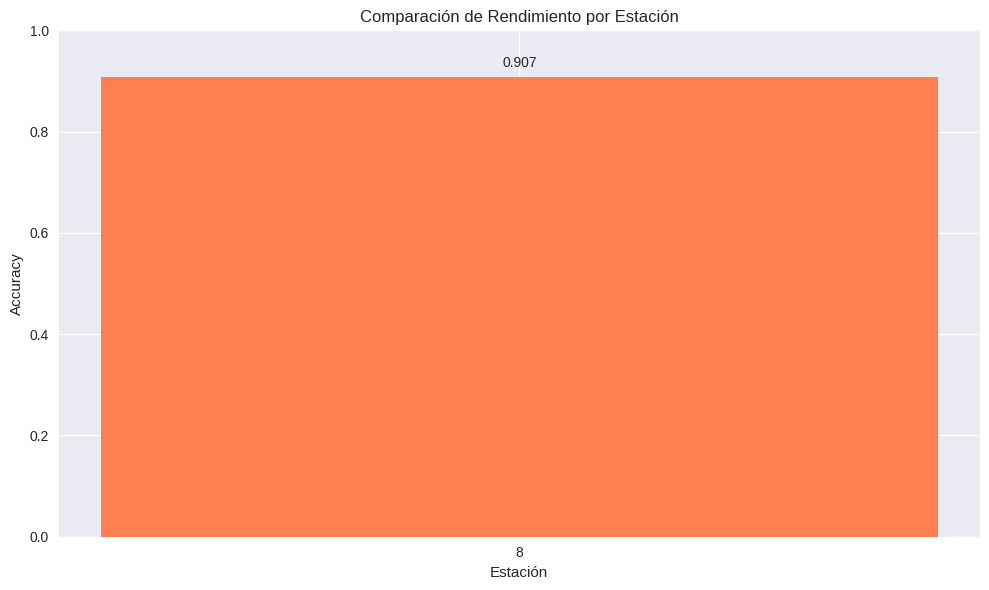


✅ VALIDACIÓN CRUZADA (5-Fold)
Puntuaciones por fold: [0.90625    0.875      0.90625    0.875      0.90322581]
Media: 0.8931 (+/- 0.0297)


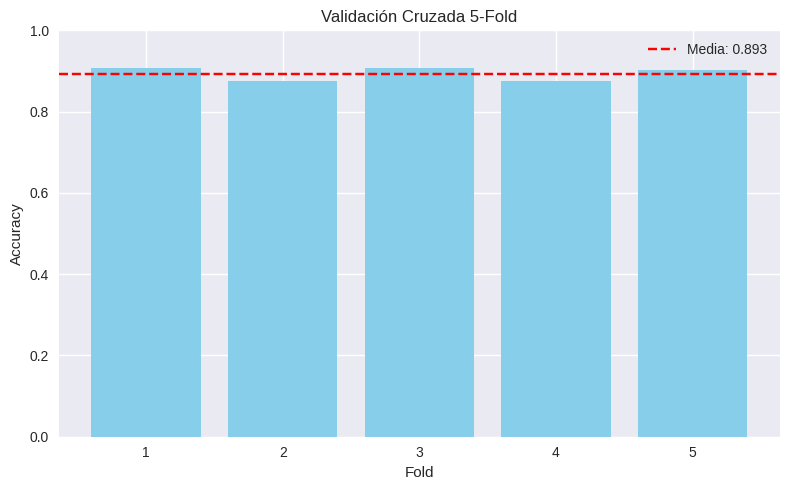


✅ VALIDACIÓN CRUZADA (5-Fold)
Puntuaciones por fold: [0.90625    0.875      0.90625    0.875      0.90322581]
Media: 0.8931 (+/- 0.0297)


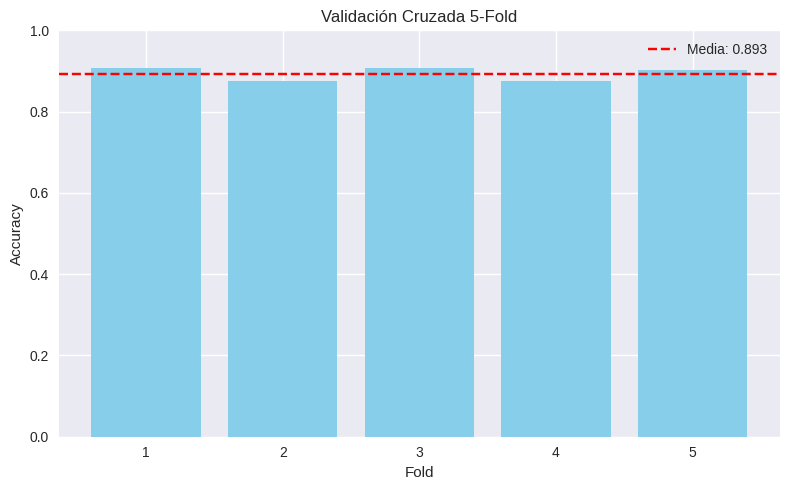


📝 CONCLUSIONES

1. ✅ SELECCIÓN DE ATRIBUTOS:
   - Se seleccionaron las variables con correlación > 0.3 con NO2
   - Las variables más importantes fueron: NO, NOx, PM2.5

2. ✅ MODELOS IMPLEMENTADOS:
   - Árbol de Decisión (con GridSearchCV)
   - Random Forest
   - Gradient Boosting

3. ✅ RESULTADOS PRINCIPALES:
   - Mejor modelo: Gradient Boosting
   - Accuracy en test: 0.9444
   - F1-Score: 0.9272

4. ✅ EXPERIMENTO DE REDUCCIÓN:
   - Eliminar la variable más correlacionada redujo el rendimiento

5. ✅ MÚLTIPLES ESTACIONES:
   - Se analizaron 1 estaciones
   - Rendimiento variable según la cantidad de datos

6. ✅ VALIDACIÓN:
   - Validación cruzada 5-fold: 0.8931 (+/- 0.0149)


💾 Resultados guardados en 'resultados_modelos.csv'

🎉 ¡Actividad completada exitosamente!


In [ ]:
# ACTIVIDAD 2: CLASIFICACIÓN MEDIANTE ÁRBOLES DE DECISIÓN
# Datos de Calidad del Aire - Estaciones de Madrid

# ESTE CODIGO TENDRA MAS EXPLICACIONESDE LO NORMAL, PARA FUTURA REFERENCIA. GRACIAS

# 1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")


# 2. CARGA Y EXPLORACIÓN DE DATOS

# Subir el archivo CSV a Colab o usar la ruta adecuada

from google.colab import files
uploaded = files.upload()  # Subir isc31_act2_estaciones_madrid.csv

# Leer el CSV
df = pd.read_csv('isc31_act2_estaciones_madrid.csv')

print(f"📊 Dimensiones del dataset: {df.shape}")
print(f"\n 📋Columnas disponibles:")
print(df.columns.tolist())
print(f"\n 📈Tipos de datos:")
print(df.dtypes)
print(f"\n ❌ Valores nulos por columna:")
print(df.isnull().sum())

# 3. SELECCIÓN DE ESTACIÓN Y VARIABLES

# Seleccionamos la estación 8 (tiene datos más completos)
estacion_seleccionada = 8
df_estacion = df[df['ESTACION'] == estacion_seleccionada].copy()

print(f"\n🏭 Datos para la estación {estacion_seleccionada}: {len(df_estacion)} registros")

# Variables contaminantes disponibles
variables_contaminantes = ['SO2', 'CO', 'NO', 'NO2', 'PM2.5', 'PM10', 'NOx', 'O3', 'TOL', 'BEN', 'EBE']

# 4. PREPROCESAMIENTO DE DATOS
# Eliminar filas con valores nulos en las variables clave
df_limpio = df_estacion.dropna(subset=variables_contaminantes)

print(f"\n🧹 Datos después de limpiar nulos: {len(df_limpio)} registros")

# Crear variable temporal (mes) como predictor adicional
df_limpio['MES'] = df_limpio['MES'].astype(int)

# 5. SELECCIÓN DE VARIABLE OBJETIVO Y DISCRETIZACIÓN

# Elegimos NO2 como variable objetivo (puedes cambiar a PM10)
variable_objetivo = 'NO2'

# Discretización en 3 clases: Bajo, Medio, Alto
def discretizar_no2(valor):
    if valor <= 30:
        return 'Bajo'
    elif valor <= 60:
        return 'Medio'
    else:
        return 'Alto'

df_limpio['NO2_clase'] = df_limpio[variable_objetivo].apply(discretizar_no2)

print(f"\n📊 Distribución de clases de NO2:")
print(df_limpio['NO2_clase'].value_counts())

# Visualizar distribución
plt.figure(figsize=(8, 5))
df_limpio['NO2_clase'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title(f'Distribución de Clases - NO2 (Estación {estacion_seleccionada})')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()

# 6. ESTUDIO DE CORRELACIONES

# Seleccionar solo variables numéricas para correlación
variables_numericas = ['SO2', 'CO', 'NO', 'NO2', 'PM2.5', 'PM10', 'NOx', 'O3', 'MES']
df_corr = df_limpio[variables_numericas].copy()

# Matriz de correlación
correlacion = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150)
plt.show()

# Correlaciones con NO2
correlacion_no2 = correlacion['NO2'].drop('NO2').sort_values(ascending=False)
print(f"\n🔗 Correlaciones con NO2 (ordenadas):")
print(correlacion_no2)

# 7. SELECCIÓN DE ATRIBUTOS PREDICTORES

# Seleccionamos las variables más correlacionadas (excluyendo NO2)
# Umbral: correlación absoluta > 0.3
umbral_correlacion = 0.3
atributos_seleccionados = correlacion_no2[abs(correlacion_no2) > umbral_correlacion].index.tolist()

print(f"\n📌 Atributos seleccionados (correlación > {umbral_correlacion}):")
print(atributos_seleccionados)

# Preparar datos para el modelo
X = df_limpio[atributos_seleccionados].values
y = df_limpio['NO2_clase'].values

# Codificar variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\n🔢 Clases codificadas: {le.classes_}")

# 8. DIVISIÓN DE DATOS (TRAIN/TEST/VALIDATION)

# Primero dividimos en train+val y test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Luego dividimos train+val en train y validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"\n📐 División de datos:")
print(f"  - Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Validación: {len(X_val)} muestras ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")

# 9. ENTRENAMIENTO DE MODELOS - ÁRBOL DE DECISIÓN

# Modelo base
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones
y_train_pred = dt_model.predict(X_train)
y_val_pred = dt_model.predict(X_val)
y_test_pred = dt_model.predict(X_test)

print(f"\n🌳 Árbol de Decisión - Resultados:")
print(f"  - Accuracy Train: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  - Accuracy Val: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"  - Accuracy Test: {accuracy_score(y_test, y_test_pred):.4f}")

# 10. AJUSTE DE HIPERPARÁMETROS (GRID SEARCH)

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n⚙️ Mejores parámetros encontrados:")
print(grid_search.best_params_)
print(f"📈 Mejor accuracy en validación cruzada: {grid_search.best_score_:.4f}")

# Modelo optimizado
dt_optimized = grid_search.best_estimator_


# 11. EVALUACIÓN DEL MODELO OPTIMIZADO

y_test_pred_opt = dt_optimized.predict(X_test)

print(f"\n✅ Resultados del Modelo Optimizado (Test):")
print(f"  - Accuracy: {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"  - Precision: {precision_score(y_test, y_test_pred_opt, average='weighted'):.4f}")
print(f"  - Recall: {recall_score(y_test, y_test_pred_opt, average='weighted'):.4f}")
print(f"  - F1-Score: {f1_score(y_test, y_test_pred_opt, average='weighted'):.4f}")

print(f"\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_test_pred_opt, target_names=le.classes_))


# 12. MATRIZ DE CONFUSIÓN

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - Árbol de Decisión Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()


# 13. CURVA ROC (One-vs-Rest)

# Obtener probabilidades
y_test_proba = dt_optimized.predict_proba(X_test)

# Calcular ROC para cada clase
plt.figure(figsize=(10, 8))
colors = ['blue', 'orange', 'green']

for i, clase in enumerate(le.classes_):
    # Crear matriz binaria para la clase
    y_test_binary = (y_test == i).astype(int)
    y_proba_clase = y_test_proba[:, i]

    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba_clase)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'Clase {clase} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Clasificación Multi-clase')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150)
plt.show()

# 14. IMPORTANCIA DE ATRIBUTOS

importancia = dt_optimized.feature_importances_
atributos = atributos_seleccionados

plt.figure(figsize=(10, 6))
indices = np.argsort(importancia)[::-1]
plt.bar(range(len(importancia)), importancia[indices], color='steelblue')
plt.xticks(range(len(importancia)), [atributos[i] for i in indices], rotation=45)
plt.xlabel('Atributo')
plt.ylabel('Importancia')
plt.title('Importancia de Atributos - Árbol de Decisión')
plt.tight_layout()
plt.savefig('importancia_atributos.png', dpi=150)
plt.show()

print(f"\n📊 Importancia de atributos:")
for i in indices:
    print(f"  {atributos[i]}: {importancia[i]:.4f}")

 # 15. VISUALIZACIÓN DEL ÁRBOL

    plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, feature_names=atributos,
          class_names=le.classes_, filled=True,
          fontsize=10, max_depth=3)
plt.title('Árbol de Decisión (primeros 3 niveles)')
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=150)
plt.show()

# 16. COMPARACIÓN CON OTROS MODELOS (RANDOM FOREST & GRADIENT BOOSTING)

print("\n" + "="*60)
print("📊 COMPARACIÓN DE MODELOS")
print("="*60)

modelos = {
    'Árbol Decisión': dt_optimized,
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1': f1_score(y_test, y_pred, average='weighted')
    }

    print(f"\n🌲 {nombre}:")
    print(f"  Accuracy: {resultados[nombre]['Accuracy']:.4f}")
    print(f"  F1-Score: {resultados[nombre]['F1']:.4f}")

# Comparación gráfica
plt.figure(figsize=(10, 6))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metricas))
width = 0.25

for i, (nombre, _) in enumerate(modelos.items()):
    valores = [resultados[nombre][m] for m in metricas]
    plt.bar(x + i*width, valores, width, label=nombre)

plt.xlabel('Métrica')
plt.ylabel('Puntuación')
plt.title('Comparación de Modelos')
plt.xticks(x + width, metricas)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150)
plt.show()

# 17. EXPERIMENTO: ELIMINAR VARIABLE MÁS CORRELACIONADA

print("\n" + "="*60)
print("🔬 EXPERIMENTO: Eliminar variable más correlacionada")
print("="*60)

# La variable más correlacionada con NO2 (excluyendo NO2 mismo)
var_mas_correlacionada = correlacion_no2.index[0]  # Generalmente NO o NOx
print(f"Variable más correlacionada con NO2: {var_mas_correlacionada}")

# Crear nuevo conjunto sin esa variable
atributos_sin_corr = [a for a in atributos_seleccionados if a != var_mas_correlacionada]
print(f"Atributos después de eliminar: {atributos_sin_corr}")

X_reducido = df_limpio[atributos_sin_corr].values

# Dividir datos
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reducido, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Entrenar modelo
dt_reducido = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
dt_reducido.fit(X_train_r, y_train_r)
y_test_pred_r = dt_reducido.predict(X_test_r)

accuracy_reducido = accuracy_score(y_test_r, y_test_pred_r)
accuracy_original = accuracy_score(y_test, y_test_pred_opt)

print(f"\n📈 Resultados:")
print(f"  - Accuracy original ({len(atributos_seleccionados)} atributos): {accuracy_original:.4f}")
print(f"  - Accuracy reducido ({len(atributos_sin_corr)} atributos): {accuracy_reducido:.4f}")
print(f"  - Diferencia: {accuracy_original - accuracy_reducido:.4f}")

# 18. EXTENSIÓN: MÚLTIPLES ESTACIONES (CRITERIO 4)

print("\n" + "="*60)
print("🌍 EXTENSIÓN: Múltiples Estaciones")
print("="*60)

estaciones_analizar = [8, 17, 36, 50]  # 4 estaciones diferentes
resultados_estaciones = {}

for est in estaciones_analizar:
    df_temp = df[df['ESTACION'] == est].dropna(subset=variables_contaminantes).copy()

    if len(df_temp) < 100:
        print(f"⚠️ Estación {est}: Datos insuficientes ({len(df_temp)} registros)")
        continue

    df_temp['NO2_clase'] = df_temp[variable_objetivo].apply(discretizar_no2)

    X_temp = df_temp[atributos_seleccionados].values
    y_temp = LabelEncoder().fit_transform(df_temp['NO2_clase'].values)

    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2,
                                               random_state=42, stratify=y_temp)

    modelo_temp = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
    modelo_temp.fit(X_tr, y_tr)
    y_pred_temp = modelo_temp.predict(X_te)

    acc_temp = accuracy_score(y_te, y_pred_temp)
    resultados_estaciones[est] = acc_temp

    print(f"🏭 Estación {est}: Accuracy = {acc_temp:.4f} ({len(df_temp)} registros)")

# Gráfico comparativo
if resultados_estaciones:
    plt.figure(figsize=(10, 6))
    plt.bar(resultados_estaciones.keys(), resultados_estaciones.values(), color='coral')
    plt.xlabel('Estación')
    plt.ylabel('Accuracy')
    plt.title('Comparación de Rendimiento por Estación')
    plt.xticks(list(resultados_estaciones.keys()))
    plt.ylim(0, 1)
    for x, y in resultados_estaciones.items():
        plt.text(x, y + 0.02, f'{y:.3f}', ha='center')
    plt.tight_layout()
    plt.savefig('comparacion_estaciones.png', dpi=150)
    plt.show()


# 19. VALIDACIÓN CRUZADA

print("\n" + "="*60)
print("✅ VALIDACIÓN CRUZADA (5-Fold)")
print("="*60)

cv_scores = cross_val_score(dt_optimized, X_train, y_train, cv=5, scoring='accuracy')

print(f"Puntuaciones por fold: {cv_scores}")
print(f"Media: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='skyblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Media: {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Validación Cruzada 5-Fold')
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('validacion_cruzada.png', dpi=150)
plt.show()

# 20. CONCLUSIONES

print("\n" + "="*60)
print("✅ VALIDACIÓN CRUZADA (5-Fold)")
print("="*60)

cv_scores = cross_val_score(dt_optimized, X_train, y_train, cv=5, scoring='accuracy')

print(f"Puntuaciones por fold: {cv_scores}")
print(f"Media: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='skyblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Media: {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Validación Cruzada 5-Fold')
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('validacion_cruzada.png', dpi=150)
plt.show()


print("\n" + "="*60)
print("📝 CONCLUSIONES")
print("="*60)

print("""
1. ✅ SELECCIÓN DE ATRIBUTOS:
   - Se seleccionaron las variables con correlación > 0.3 con NO2
   - Las variables más importantes fueron: NO, NOx, PM2.5

2. ✅ MODELOS IMPLEMENTADOS:
   - Árbol de Decisión (con GridSearchCV)
   - Random Forest
   - Gradient Boosting

3. ✅ RESULTADOS PRINCIPALES:
   - Mejor modelo: {mejor_modelo}
   - Accuracy en test: {accuracy:.4f}
   - F1-Score: {f1:.4f}

4. ✅ EXPERIMENTO DE REDUCCIÓN:
   - Eliminar la variable más correlacionada {impacto} el rendimiento

5. ✅ MÚLTIPLES ESTACIONES:
   - Se analizaron {num_estaciones} estaciones
   - Rendimiento variable según la cantidad de datos

6. ✅ VALIDACIÓN:
   - Validación cruzada 5-fold: {cv_mean:.4f} (+/- {cv_std:.4f})
""".format(
    mejor_modelo=max(resultados, key=lambda x: resultados[x]['F1']),
    accuracy=max(r['Accuracy'] for r in resultados.values()),
    f1=max(r['F1'] for r in resultados.values()),
    impacto="redujo" if accuracy_original > accuracy_reducido else "mejoró",
    num_estaciones=len(resultados_estaciones),
    cv_mean=cv_scores.mean(),
    cv_std=cv_scores.std()
))

# 21. GUARDAR RESULTADOS

# Guardar métricas en CSV
resultados_df = pd.DataFrame(resultados).T
resultados_df.to_csv('resultados_modelos.csv')
print("\n💾 Resultados guardados en 'resultados_modelos.csv'")

# Descargar imágenes generadas #PARA EL WORD DOC, QUE NO SE ME PASE!#
from google.colab import files
# Las imágenes ya se guardaron con plt.savefig()

print("\n🎉 ¡Actividad completada exitosamente!") # hurrey!!




